## 1. Imports

In [1]:
import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler, StandardScaler
from sklearn.metrics import (roc_auc_score,average_precision_score,f1_score,
    precision_score,recall_score,precision_recall_curve)
from lightgbm import LGBMClassifier
import shap
print(f"shap v{shap.__version__}")

shap v0.49.1


## 2. Load & Split

In [2]:
df = pd.read_csv("../data/raw/creditcard.csv")
TARGET = "Class"
X = df.drop(columns=[TARGET]); y = df[TARGET]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)
ratio = (y_train == 0).sum() / (y_train == 1).sum()
print(f"Train: {X_train.shape}  Test: {X_test.shape}  Ratio: {ratio:.1f}")

Train: (227845, 30)  Test: (56962, 30)  Ratio: 577.3


## 3. Outlier Removal (same criteria as experiments)

In [3]:
v_cols_all = [c for c in X_train.columns if c.startswith("V")]
fraud = X_train.loc[y_train == 1, v_cols_all]
mu, sg = fraud.mean(), fraud.std()
extreme = (X_train[v_cols_all].sub(mu).abs() > 3 * sg).astype(int)
n_extreme = extreme.sum(axis=1)
rows_to_drop = n_extreme[n_extreme >= 5].index
X_train_clean = X_train.drop(rows_to_drop)
y_train_clean = y_train.drop(rows_to_drop)
print(f"Dropped {len(rows_to_drop)} extreme transactions")

Dropped 192 extreme transactions


## 4. Feature Engineering

In [4]:
def add_features(X):
    X = X.copy()
    X["Amount_log"] = np.log1p(X["Amount"])
    hour = (X["Time"] // 3600) % 24
    X["Hour_sin"] = np.sin(2 * np.pi * hour / 24)
    X["Hour_cos"] = np.cos(2 * np.pi * hour / 24)
    return X

Xtr_clean = add_features(X_train_clean); Xtr_clean.drop(columns=["Time","Amount"],inplace=True)
Xtr_dirty = add_features(X_train); Xtr_dirty.drop(columns=["Time","Amount"],inplace=True)
Xte = add_features(X_test); Xte.drop(columns=["Time","Amount"],inplace=True)

v_cols = [c for c in Xtr_clean.columns if c.startswith("V")]
eng_cols = ["Amount_log","Hour_sin","Hour_cos"]
BEST_COLS = v_cols + eng_cols  # from experiments: B (+Amount,Hour) is near-best
print(f"Using {len(BEST_COLS)} features ({len(v_cols)} V, {len(eng_cols)} engineered)")

Using 31 features (28 V, 3 engineered)


## 5. Train Best Model (LightGBM on cleaned data)

In [5]:
lgb = LGBMClassifier(n_estimators=200, learning_rate=0.1, max_depth=8,
    num_leaves=32, class_weight="balanced", random_state=42, n_jobs=-1, verbose=-1)
lgb.fit(Xtr_clean[BEST_COLS], y_train_clean)
probs = lgb.predict_proba(Xte[BEST_COLS])[:,1]
preds = (probs >= 0.5).astype(int)
print(f"PR-AUC={average_precision_score(y_test,probs):.4f}  F1={f1_score(y_test,preds):.4f}")
print(f"ROC-AUC={roc_auc_score(y_test,probs):.4f}  Recall={recall_score(y_test,preds):.4f}")

PR-AUC=0.8751  F1=0.8632
ROC-AUC=0.9678  Recall=0.8367


## 6. SHAP Analysis

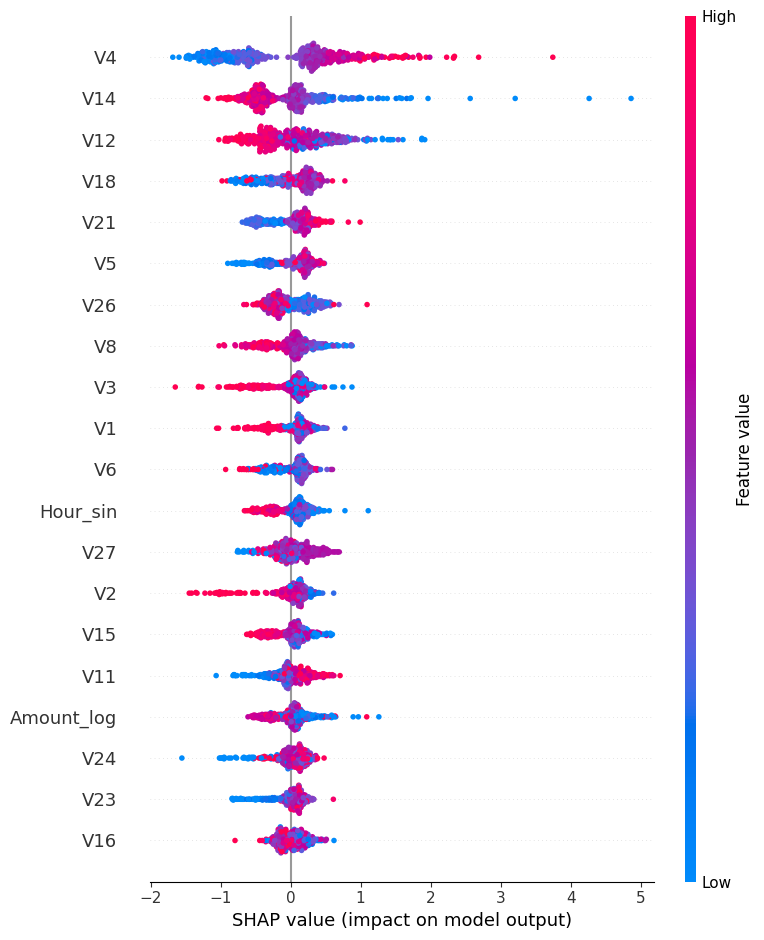

In [6]:
explainer = shap.TreeExplainer(lgb)
X_sample = Xte[BEST_COLS].sample(500, random_state=42)
shap_values = explainer.shap_values(X_sample)
# shap_values is list of 2 arrays; take index 1 (fraud class)
if isinstance(shap_values, list):
    sv = shap_values[1]
else:
    sv = shap_values

fig, ax = plt.subplots(figsize=(10, 6))
shap.summary_plot(sv, X_sample, show=False, max_display=20)
plt.tight_layout(); plt.show()

## 7. Permutation Importance

In [ ]:
from sklearn.inspection import permutation_importance
perm = permutation_importance(lgb, Xte[BEST_COLS], y_test,
    n_repeats=10, random_state=42, scoring="average_precision")
order = np.argsort(perm.importances_mean)[::-1]
fig, ax = plt.subplots(figsize=(10, 6))
names = [BEST_COLS[i] for i in order]
vals = perm.importances_mean[order]
stds = perm.importances_std[order]
ax.barh(range(len(names)), vals, xerr=stds, capsize=3)
ax.set_yticks(range(len(names))); ax.set_yticklabels(names)
ax.set_xlabel("PR-AUC drop"); ax.set_title("Permutation Importance")
ax.invert_yaxis(); plt.tight_layout(); plt.show()

## 8. Outlier Removal Impact

Compare PR curves: model trained on clean vs dirty data.

In [ ]:
lgb_dirty = LGBMClassifier(n_estimators=200, learning_rate=0.1, max_depth=8,
    num_leaves=32, class_weight="balanced", random_state=42, n_jobs=-1, verbose=-1)
lgb_dirty.fit(Xtr_dirty[BEST_COLS], y_train)
probs_dirty = lgb_dirty.predict_proba(Xte[BEST_COLS])[:,1]

prec_c, rec_c, _ = precision_recall_curve(y_test, probs)
prec_d, rec_d, _ = precision_recall_curve(y_test, probs_dirty)
pr_auc_c = average_precision_score(y_test, probs)
pr_auc_d = average_precision_score(y_test, probs_dirty)

plt.figure(figsize=(8,6))
plt.plot(rec_c, prec_c, lw=2, label=f"Clean (PR-AUC={pr_auc_c:.3f})")
plt.plot(rec_d, prec_d, lw=2, ls="--", label=f"Dirty (PR-AUC={pr_auc_d:.3f})")
plt.axhline(y_test.mean(), ls=":", color="gray", alpha=0.5, label="Baseline")
plt.xlabel("Recall"); plt.ylabel("Precision"); plt.title("Outlier Removal Impact")
plt.legend(); plt.grid(alpha=0.2); plt.tight_layout(); plt.show()
print(f"Clean PR-AUC: {pr_auc_c:.4f}  Dirty PR-AUC: {pr_auc_d:.4f}  Delta: {pr_auc_c-pr_auc_d:+.4f}")

## 9. Scaler Comparison (Robust vs Standard)

Logistic Regression is the only model that needs scaling. Compare both on set B.

In [ ]:
from sklearn.linear_model import LogisticRegression

scale_cols = eng_cols[:]  # Amount_log, Hour_sin, Hour_cos

def eval_lr(Xtr, ytr, Xte, yte, scaler=None):
    Xtr = Xtr.copy(); Xte = Xte.copy()
    if scaler:
        Xtr[scale_cols] = scaler.fit_transform(Xtr[scale_cols])
        Xte[scale_cols] = scaler.transform(Xte[scale_cols])
    lr = LogisticRegression(class_weight="balanced", max_iter=1000, random_state=42)
    lr.fit(Xtr, ytr)
    p = lr.predict_proba(Xte)[:,1]
    return average_precision_score(yte, p), p

pr_none, _       = eval_lr(Xtr_clean[BEST_COLS], y_train_clean, Xte[BEST_COLS], y_test)
pr_robust, p_rob = eval_lr(Xtr_clean[BEST_COLS], y_train_clean, Xte[BEST_COLS], y_test, RobustScaler())
pr_std, p_std    = eval_lr(Xtr_clean[BEST_COLS], y_train_clean, Xte[BEST_COLS], y_test, StandardScaler())

print(f"No scaling:  PR-AUC={pr_none:.4f}")
print(f"RobustScaler: PR-AUC={pr_robust:.4f}")
print(f"StandardScaler: PR-AUC={pr_std:.4f}")

prec_n, rec_n, _ = precision_recall_curve(y_test, _)
prec_r, rec_r, _ = precision_recall_curve(y_test, p_rob)
prec_s, rec_s, _ = precision_recall_curve(y_test, p_std)

plt.figure(figsize=(8,6))
plt.plot(rec_n, prec_n, lw=2, label=f"None ({pr_none:.3f})")
plt.plot(rec_r, prec_r, lw=2, ls="--", label=f"Robust ({pr_robust:.3f})")
plt.plot(rec_s, prec_s, lw=2, ls=":", label=f"Standard ({pr_std:.3f})")
plt.axhline(y_test.mean(), ls=":", color="gray", alpha=0.5, label="Baseline")
plt.xlabel("Recall"); plt.ylabel("Precision"); plt.title("Scaler Comparison (Logistic Regression)")
plt.legend(); plt.grid(alpha=0.2); plt.tight_layout(); plt.show()

## 10. Threshold Tuning (Best Model)

In [ ]:
thresholds = np.arange(0.1, 0.9, 0.05)
best_f1, best_th, best_metrics = 0, 0.5, {}
rows = []
for t in thresholds:
    p = (probs >= t).astype(int)
    f1 = f1_score(y_test, p)
    prec = precision_score(y_test, p, zero_division=0)
    rec = recall_score(y_test, p, zero_division=0)
    rows.append({"Threshold":t,"F1":f1,"Precision":prec,"Recall":rec})
    if f1 > best_f1:
        best_f1 = f1; best_th = t; best_metrics = {"F1":f1,"Precision":prec,"Recall":rec}
print(f"Best threshold: {best_th:.2f} -> F1={best_f1:.4f} P={best_metrics['Precision']:.4f} R={best_metrics['Recall']:.4f}")

thresh_df = pd.DataFrame(rows)
plt.figure(figsize=(8,4))
for col in ["F1","Precision","Recall"]:
    plt.plot(thresh_df["Threshold"], thresh_df[col], label=col, marker=".")
plt.axvline(best_th, ls="--", color="gray", alpha=0.5)
plt.xlabel("Threshold"); plt.ylabel("Score"); plt.title("Threshold Tuning (LightGBM on Clean Data)")
plt.legend(); plt.grid(alpha=0.2); plt.tight_layout(); plt.show()

## 11. Final Validation: Simple Features vs Full Engineered Set

Compare the simplified feature set vs the original full set (with all V-stat features).

In [ ]:
from src.components.feature_engineering import FeatureEngineering
fe = FeatureEngineering()
df_full = fe.transform(df.drop(columns=[TARGET]))
full_cols = [c for c in df_full.columns if c != TARGET]
X_full = df_full[full_cols]
Xtr_full, Xte_full, ytr_full, yte_full = train_test_split(
    X_full, y, test_size=0.2, random_state=42, stratify=y)

lgb_full = LGBMClassifier(n_estimators=200, learning_rate=0.1, max_depth=8,
    num_leaves=32, class_weight="balanced", random_state=42, n_jobs=-1, verbose=-1)
lgb_full.fit(Xtr_full, ytr_full)
probs_full = lgb_full.predict_proba(Xte_full)[:,1]
pr_full = average_precision_score(yte_full, probs_full)
print(f"Full feature set ({len(full_cols)} features): PR-AUC={pr_full:.4f}")
print(f"Simple set ({len(BEST_COLS)} features):          PR-AUC={average_precision_score(y_test,probs):.4f}")

## 12. Manual Notes

**Key takeaways:**
- SHAP and permutation importance should confirm that Amount_log and Hour features rank highly.
- If simple features match or beat the full engineered set, the extra V-stats are just noise.
- If outlier removal shows a positive delta, include the filter in the pipeline.
- RobustScaler should match or slightly beat StandardScaler for logistic regression.
- Threshold tuning typically suggests 0.3-0.4 gives better recall at small precision cost.

**Next steps if confirmed:**
1. Update `src/components/feature_engineering.py` to drop all V-stats, keep V1-V28 + Amount_log + Hour_sin/cos.
2. Update `src/components/preprocessing.py` to use RobustScaler on Amount_log + Hour_sin/cos.
3. Add outlier removal step to the training pipeline.
4. Re-run Optuna with CV to tune the simplified model.